In [22]:
import kagglehub
import shutil
path = kagglehub.dataset_download("anninasimon/employee-salary-dataset")

# Copy the dataset to your Google Drive
shutil.copytree(
    path,
    "/content/drive/MyDrive/AML_MSIS/DataSets/employee-salary-dataset",
    dirs_exist_ok=True
)

path = kagglehub.dataset_download("muhamedumarjamil/student-placement-data-with-cgpa-and-salary")

# Copy the dataset to your Google Drive
shutil.copytree(
    path,
    "/content/drive/MyDrive/AML_MSIS/DataSets/student-placement",
    dirs_exist_ok=True
)
print("Dataset saved to Google Drive!")



Using Colab cache for faster access to the 'employee-salary-dataset' dataset.


100%|██████████| 8.61k/8.61k [00:00<00:00, 4.84MB/s]

Extracting files...
Dataset saved to Google Drive!



 MAE : 8.910810209277825

 MSE : 100.25407766842153

 RMSE : 10.01269582422344

 R2 Score : 0.00488220094606473


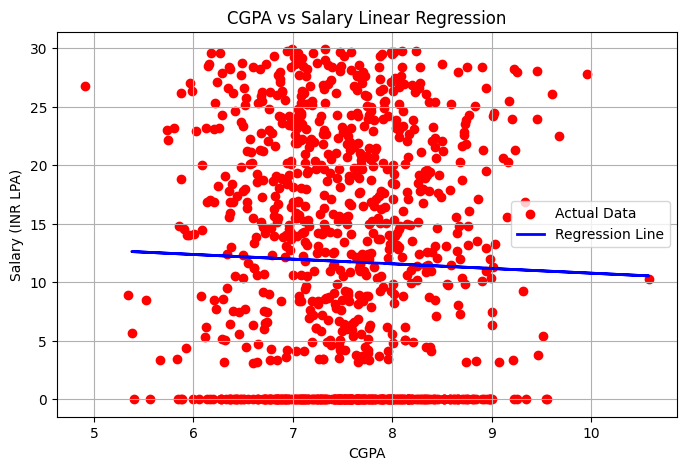

In [32]:
from numpy.random import RandomState
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split


# df = pd.read_csv("/content/drive/MyDrive/AML_MSIS/DataSets/Employee_Salary_Dataset.csv")
df = pd.read_csv("/content/drive/MyDrive/AML_MSIS/DataSets/Placement.csv")

df.head()

X = df[['CGPA']]
y = df['Salary (INR LPA)']


X_train,X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2,random_state=42)

model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


print("\n MAE :",mean_absolute_error(y_test,y_pred))
print("\n MSE :",mean_squared_error(y_test,y_pred))
print("\n RMSE :",np.sqrt(mean_squared_error(y_test,y_pred)))
print("\n R2 Score :",r2_score(y_test,y_pred))



import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['CGPA'],
            df['Salary (INR LPA)'],
            color = 'red',
            label = 'Actual Data'
            )
plt.plot(
    X_test['CGPA'],
    y_pred,
    color='blue',
    linewidth=2,
    label='Regression Line'
)
plt.xlabel('CGPA')
plt.ylabel('Salary (INR LPA)')
plt.title('CGPA vs Salary Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

